# Transport coefficients of the QGP from the MLQGPS emulator (B = 0)

Formulas: Singh & Sahoo, Phys. Rev. D 112, 034032 (2025): electrical conductivity and Eq. (19).
Only the relaxation time (WB fit, Plumari et al.) and the DNN masses / thermodynamics are from the notebook.

Order: every calculation block is followed by its own plot block, and the emulator is called once (Block 4).

| Block | Content |
|---|---|
| 1 | Setup, constants, plot helper |
| 2-3 | Model and emulator |
| 4-5 | Emulate at fixed muB, plot masses and enthalpy |
| 6-7 | tau_q, tau_g, plot |
| 8-9 | electrical conductivity, plot |
| 10-11 | kappa at zero current, Lorenz number, plot |
| 12 | Save CSV |

In [41]:
# Block 1
# Imports, paths, constants and a plot helper

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import quad

warnings.filterwarnings("ignore", category=UserWarning)

# ---------- paths ----------
_cwd = os.getcwd()
if os.path.isfile(os.path.join(_cwd, "Thermo_data_central.csv")):
    ROOT = _cwd
elif os.path.isfile(os.path.join(os.path.dirname(_cwd), "Thermo_data_central.csv")):
    ROOT = os.path.dirname(_cwd)
else:
    raise FileNotFoundError("Thermo_data_central.csv not found. Set ROOT by hand.")

os.chdir(ROOT)
WDIR = os.path.join(ROOT, "mlqgps_model")           # trained weights
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- constants ----------
Tc    = 0.155                                       # GeV
nc    = 3
nf    = 3
e     = np.sqrt(4*np.pi/137)                        # electric charge, alpha_em = 1/137
coeff = (4*np.pi) / (3*(2*np.pi)**3)                # angular average x d^3k/(2pi)^3 = 1/(6 pi^2)

# ---------- your tau: WB fit (Plumari et al.) ----------
lambda_WB, Ts_Tc_WB, kwb = 2.6, 0.57, 18.5

# ---------- fixed baryon chemical potentials ----------
muB_list = [0.1, 0.3, 0.6]                          # GeV
colors   = {0.1: "#2A9D8F", 0.3: "#3A86FF", 0.6: "#E76F51"}

# ---------- plot helper: one curve per muB ----------
def plot_fixed_muB(data, key, ylabel, fname, hline=None):
    plt.figure(figsize=(10, 6))
    for muB_val in muB_list:
        r = data[muB_val]
        plt.plot(r["T"]/Tc, r[key], marker=".", color=colors[muB_val], label=rf"$\mu_B={muB_val}$ GeV")
    if hline is not None:
        plt.axhline(hline, color="gray", ls="--", lw=1)
    plt.xlabel(r"$T/T_c$", fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.legend(loc="best", fontsize=14)
    plt.grid(True)
    plt.xlim(1.1, 1.55)
    plt.tick_params(which="both", direction="in", top=True, right=True)
    plt.savefig(os.path.join(ROOT, "plots", fname), dpi=200, bbox_inches="tight")
    plt.show()

print("ROOT   :", ROOT)
print("weights:", WDIR)
print("device :", device)

ROOT   : d:\ML CURSOR\MLQGP
weights: d:\ML CURSOR\MLQGP\mlqgps_model
device : cuda


In [42]:
# Block 2
# MLQGPS DNN: Input(2) -> Linear(64, swish) x4 -> Linear(1), 2*sigmoid
# and the partition functions of quarks and gluons

class Net_Mass(nn.Module):
    def __init__(self, input, output):
        super(Net_Mass, self).__init__()
        self.fc1 = nn.Linear(input, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, output)

    def forward(self, x):
        o = self.act(self.fc1(x))
        o = self.act(self.fc2(o))
        o = self.act(self.fc3(o))
        o = self.act(self.fc4(o))
        opt = self.output_layer_act(self.fc5(o))
        return opt

    def act(self, x):
        return x * torch.sigmoid(x)

    def output_layer_act(self, x):
        return torch.sigmoid(x) * 2


def lnZ_q(T, m, mu, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    rnodes = torch.exp(-pnodes)
    psqure = pnodes**2
    E = (psqure + m ** 2) ** 0.5
    E_mu = E - mu
    efactor = torch.exp(-E_mu/T)
    f = efactor * eta
    f = f + 1
    f = torch.log(f)
    f = psqure * eta * f
    f = wnodes * f
    f = f/rnodes
    f = torch.sum(f, 1)
    return f.reshape(-1, 1)


def lnZ_g(T, m, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    rnodes = torch.exp(-pnodes)
    psqure = pnodes**2
    E = (psqure + m ** 2) ** 0.5
    efactor = torch.exp(-E/T)
    f = efactor * eta
    f = f + 1
    f = torch.log(f)
    f = psqure * eta * f
    f = wnodes * f
    f = f/rnodes
    f = torch.sum(f, 1)
    return f.reshape(-1, 1)

In [43]:
# Block 3
# Emulator: load the trained MLQGPS weights, thermodynamics from lnZ

Mud_net = Net_Mass(2, 1).to(device)
Ms_net  = Net_Mass(2, 1).to(device)
Mg_net  = Net_Mass(2, 1).to(device)
Mud_net.load_state_dict(torch.load(os.path.join(WDIR, "MLQGPS_Mud.pt"), map_location=device, weights_only=False)['state_dict'])
Ms_net.load_state_dict(torch.load(os.path.join(WDIR, "MLQGPS_Ms.pt"),  map_location=device, weights_only=False)['state_dict'])
Mg_net.load_state_dict(torch.load(os.path.join(WDIR, "MLQGPS_Mg.pt"),  map_location=device, weights_only=False)['state_dict'])
Mud_net.eval(); Ms_net.eval(); Mg_net.eval()
print("Loaded MLQGPS weights from", WDIR)


def emulator(T_values, muB_values):

    T   = torch.tensor(T_values,   dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)
    muB = torch.tensor(muB_values, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)

    inp = torch.cat((T, muB), dim=1)
    Mud = Mud_net(inp)
    Ms  = Ms_net(inp)
    Mg  = Mg_net(inp)

    coef_ud = 2*2*3/(2*np.pi**2)
    coef_s  = 2*3/(2*np.pi**2)
    coef_g  = 8*2/(2*np.pi**2)

    lnZ_udquark = coef_ud * (lnZ_q(T, Mud, muB/3, 1) + lnZ_q(T, Mud, -muB/3, 1))
    lnZ_squark  = coef_s  * (lnZ_q(T, Ms,  muB/3, 1) + lnZ_q(T, Ms,  -muB/3, 1))
    lnZ_gluon   = coef_g  * lnZ_g(T, Mg, -1)

    lnZ_tot = lnZ_udquark + lnZ_squark + lnZ_gluon

    dlnZdT  = torch.autograd.grad(lnZ_tot, T,   grad_outputs=torch.ones_like(T).to(device),   create_graph=True)[0]
    dlnZdmu = torch.autograd.grad(lnZ_tot, muB, grad_outputs=torch.ones_like(muB).to(device), create_graph=True)[0]

    BaryonNumber = T * dlnZdmu                              # net baryon density
    Pressure     = T * lnZ_tot
    Entropy      = T * dlnZdT + lnZ_tot
    Energy       = T * Entropy - Pressure + muB * BaryonNumber
    TraceAnomaly = Energy - 3 * Pressure

    return (
        Mud.detach().cpu().numpy().flatten(),
        Ms.detach().cpu().numpy().flatten(),
        Mg.detach().cpu().numpy().flatten(),
        Pressure.detach().cpu().numpy().flatten(),
        Entropy.detach().cpu().numpy().flatten(),
        Energy.detach().cpu().numpy().flatten(),
        TraceAnomaly.detach().cpu().numpy().flatten(),
        BaryonNumber.detach().cpu().numpy().flatten(),
        T.detach().cpu().numpy().flatten(),
        muB.detach().cpu().numpy().flatten(),
    )

Loaded MLQGPS weights from d:\ML CURSOR\MLQGP\mlqgps_model


In [44]:
# Block 4  (emulation only, no plots)
# Call the emulator once at fixed muB and store everything in the dictionary emu

_thermo = pd.read_csv(os.path.join(ROOT, "Thermo_data_central.csv"))
T_data  = np.sort(np.unique(_thermo["T"].to_numpy(dtype=float)))
T_fix   = T_data[(T_data/Tc >= 1.10) & (T_data/Tc <= 1.55)]
print("T points:", len(T_fix), " range:", float(T_fix.min()), "-", float(T_fix.max()), "GeV")

emu = {}
for muB_val in muB_list:
    muB_arr = np.full(T_fix.shape, muB_val, dtype=np.float64)
    mud_f, ms_f, mg_f, pr_f, s_f, en_f, tr_f, nB_f, T_f, Mu_f = emulator(T_fix, muB_arr)

    emu[muB_val] = {
        "T":     T_f.astype(float),
        "muB":   Mu_f.astype(float),
        "mud":   mud_f.astype(float),
        "ms":    ms_f.astype(float),
        "mg":    mg_f.astype(float),
        "P":     pr_f.astype(float),
        "s":     s_f.astype(float),
        "eps":   en_f.astype(float),
        "trace": tr_f.astype(float),
        "nB":    nB_f.astype(float),
        "xi":    ((en_f + pr_f) / nB_f).astype(float),      # enthalpy per baryon, GeV
    }
    print("muB =", muB_val, " done")

T points: 70  range: 0.171 - 0.24 GeV
muB = 0.1  done
muB = 0.3  done
muB = 0.6  done


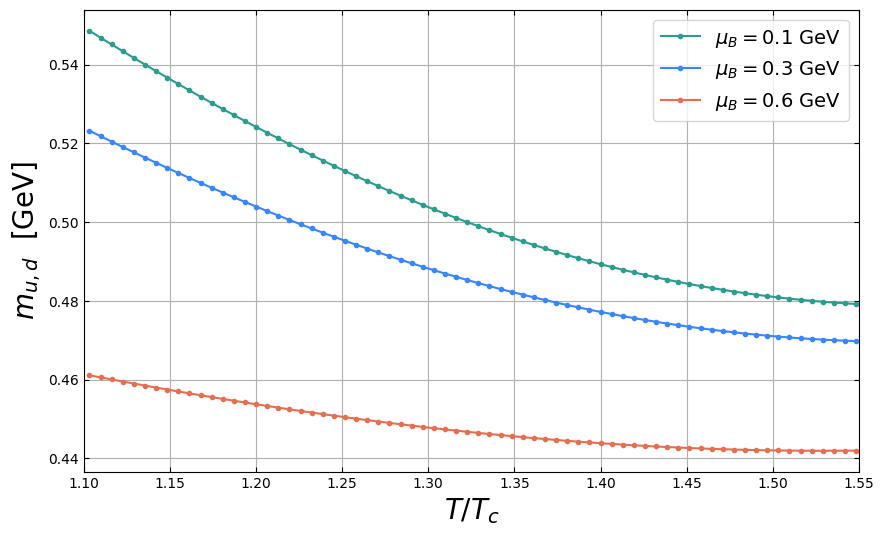

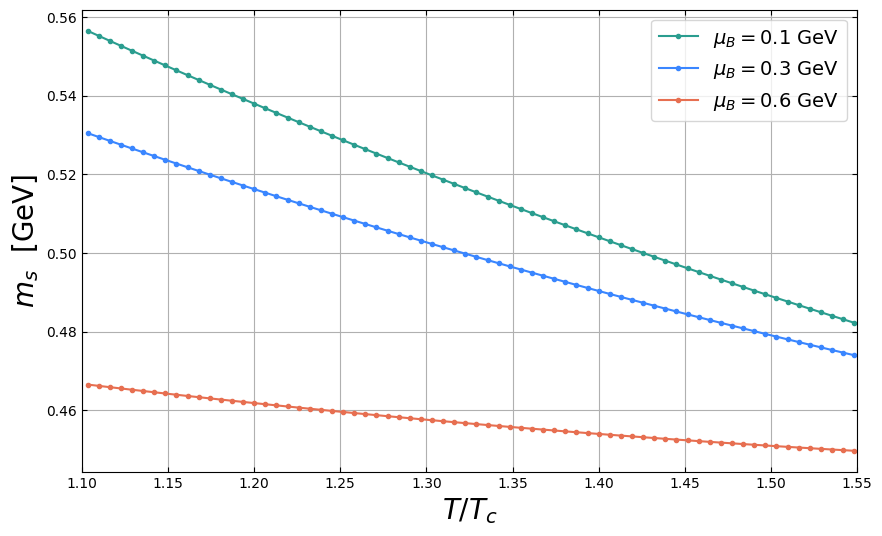

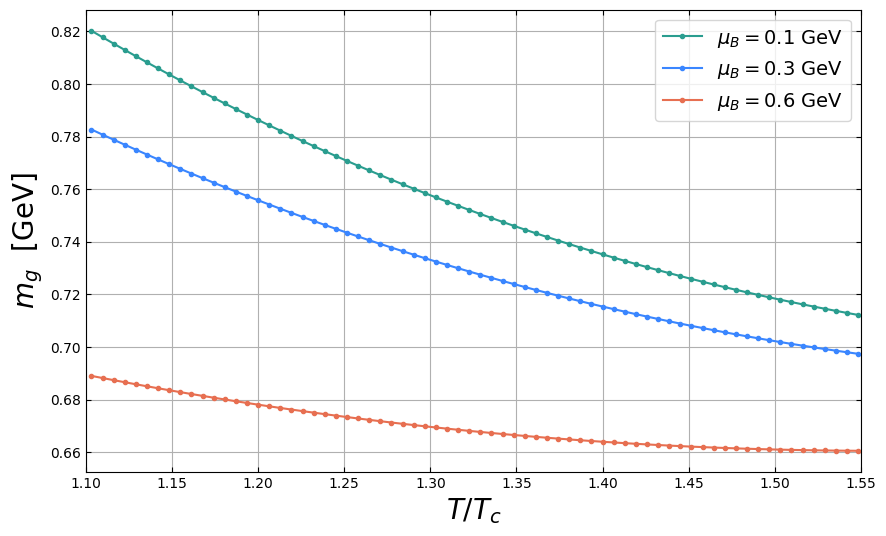

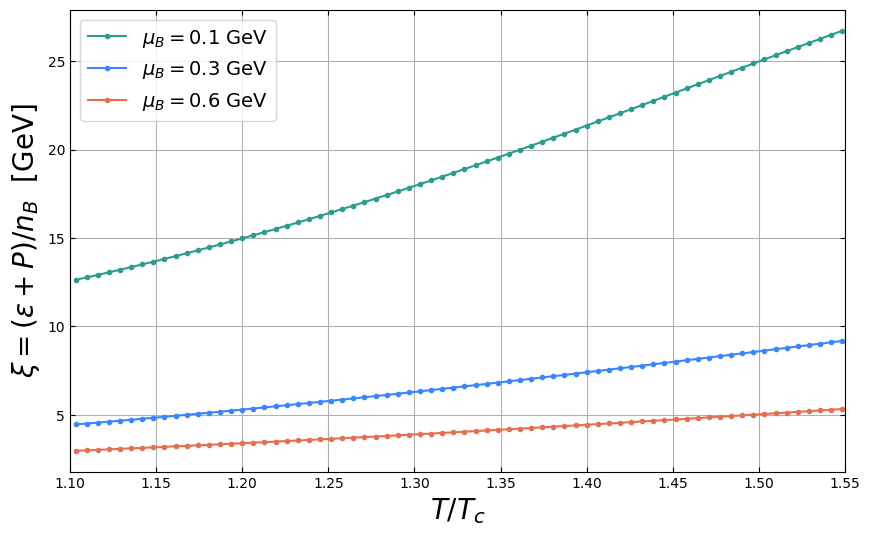

In [45]:
# Block 5  (plots)
# Masses and enthalpy per baryon xi = (eps + P)/n_B

plot_fixed_muB(emu, "mud", r"$m_{u,d}$  [GeV]", "mass_ud.jpg")
plot_fixed_muB(emu, "ms",  r"$m_{s}$  [GeV]",   "mass_s.jpg")
plot_fixed_muB(emu, "mg",  r"$m_{g}$  [GeV]",   "mass_g.jpg")
plot_fixed_muB(emu, "xi",  r"$\xi=(\varepsilon+P)/n_B$  [GeV]", "enthalpy.jpg")

In [46]:
# Block 6  (calculation)
# Your tau (WB fit, Plumari et al.): tau_q and tau_g in fm/c, from the running coupling g^2(T)

tau = {}
for muB_val in muB_list:
    T = emu[muB_val]["T"]

    g2 = 48*np.pi**2 / (((11*nc) - (2*nf)) * np.log((lambda_WB*(T/Tc - Ts_Tc_WB))**2))

    tauq_inv = (nc**2 - 1)/nc * (g2*T)/(8*np.pi) * np.log(2*kwb/g2) * 5.07      # 1/fm
    taug_inv = 2*nc           * (g2*T)/(8*np.pi) * np.log(2*kwb/g2) * 5.07      # 1/fm

    tau[muB_val] = {"T": T, "g2": g2, "tq": 1.0/tauq_inv, "tg": 1.0/taug_inv}   # fm/c

print("tau_q range [fm/c]:", tau[muB_list[0]]["tq"].min(), "-", tau[muB_list[0]]["tq"].max())

tau_q range [fm/c]: 0.6014277840388039 - 1.2629882653386824


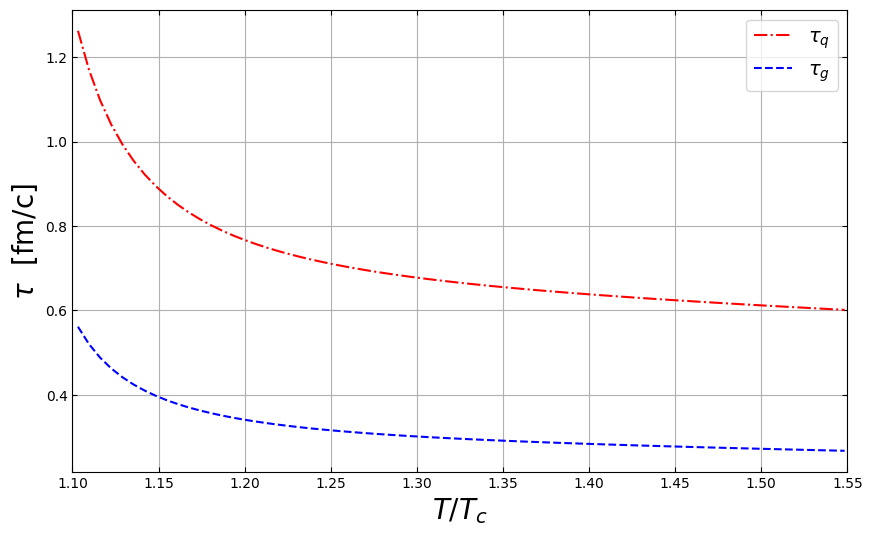

In [47]:
# Block 7  (plot)
# tau_q and tau_g (they depend on T only, not on muB)

r = tau[muB_list[0]]
plt.figure(figsize=(10, 6))
plt.plot(r["T"]/Tc, r["tq"], ls="-.", color="red",  label=r"$\tau_q$")
plt.plot(r["T"]/Tc, r["tg"], ls="--", color="blue", label=r"$\tau_g$")
plt.xlabel(r"$T/T_c$", fontsize=20)
plt.ylabel(r"$\tau$  [fm/c]", fontsize=20)
plt.legend(loc="best", fontsize=14)
plt.grid(True)
plt.xlim(1.1, 1.55)
plt.tick_params(which="both", direction="in", top=True, right=True)
plt.savefig(os.path.join(ROOT, "plots", "tau.jpg"), dpi=200, bbox_inches="tight")
plt.show()

In [48]:
# Block 8  (calculation)
# sigma_el at B = 0:
#   sigma_el = sum_i g_i/(3T) Int d^3k/(2pi)^3 tau q^2 (k/w)^2 f(1-f)
# Charges: u +2/3, d -1/3, s -1/3 (antiquarks the same, since q^2).
# Inside every function: p = |k|, Tmp = T, tq = tau in fm (5.07 converts to GeV^-1), Mu = quark chemical potential muB/3.

# ---------------- sigma integrands (q^2 e^2) ----------------
def sig_u_q(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    return (p**4 / En**2) * (2/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_u_a(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    return (p**4 / En**2) * (2/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_d_q(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    return (p**4 / En**2) * (1/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_d_a(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    return (p**4 / En**2) * (1/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_s_q(p, mass_s, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    return (p**4 / En**2) * (1/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_s_a(p, mass_s, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    return (p**4 / En**2) * (1/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

# ---------------- main loop ----------------
trans = {}
for muB_val in muB_list:
    d    = emu[muB_val]
    T_f  = d["T"]
    tq_f = tau[muB_val]["tq"]
    Mu_q = d["muB"] / 3.0

    sig_list = []
    for mass_ud, mass_s, Tmp, tq, Mu in zip(d["mud"], d["ms"], T_f, tq_f, Mu_q):
        mass_ud, mass_s, Tmp, tq, Mu = map(float, (mass_ud, mass_s, Tmp, tq, Mu))

        a = (mass_ud, Tmp, tq, Mu)
        b = (mass_s,  Tmp, tq, Mu)
        sig_tot = (quad(sig_u_q, 0, 10, args=a)[0] + quad(sig_u_a, 0, 10, args=a)[0]
                 + quad(sig_d_q, 0, 10, args=a)[0] + quad(sig_d_a, 0, 10, args=a)[0]
                 + quad(sig_s_q, 0, 10, args=b)[0] + quad(sig_s_a, 0, 10, args=b)[0])
        sig_list.append(sig_tot)

    sigma_f = np.array(sig_list) * coeff             # sigma_el  [GeV]
    sigT_f  = sigma_f / T_f                          # sigma_el / T

    trans[muB_val] = {"T": T_f, "sigma": sigma_f, "sigT": sigT_f}
    print("muB =", muB_val, " done")

muB = 0.1  done
muB = 0.3  done
muB = 0.6  done


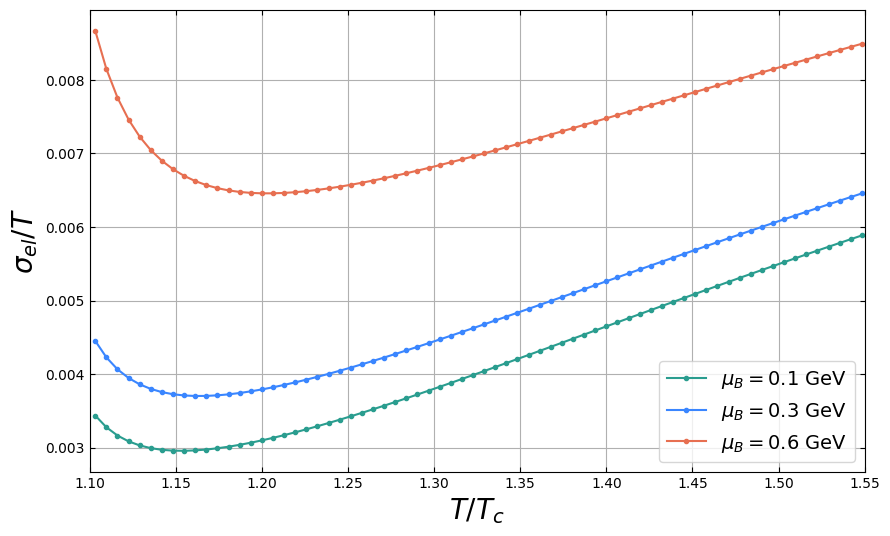

In [49]:
# Block 9  (plots)

plot_fixed_muB(trans, "sigT", r"$\sigma_{el}/T$", "sigmabyT.jpg")

In [50]:
# Block 10  (calculation)
# kappa0, Eq. (19): heat conductivity at fixed xi (electric field free to adjust)
#   kappa0 = sum_i g_i/(3T^2) Int d^3k/(2pi)^3 tau (k/w)^2 (w - b xi)^2 f(1-f)
# I1 is computed only to remove the electric-current piece. It is not plotted.
#   I1 = sum_i g_i/(3T) Int d^3k/(2pi)^3 tau q (k/w)^2 (w - b xi) f(1-f)
# Wiedemann-Franz uses the heat conductivity at zero electric current:
#   kappa = kappa0 - I1^2 / (T sigma_el)
#   L = kappa / (sigma_el T),   L0 = pi^2 / (3 e^2),   ratio L/L0
# Same coeff, 5.07 and e as Block 8. kappa and kappa0 are in GeV^2; L is dimensionless.

with_gluon = False        # True adds gluons: Bose factor f(1+f), b = 0, g = 16, tau_g from Block 6

# ---------------- kappa0 integrands (no charge, so no e) ----------------
def kap_ud_q(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (tq / Tmp**2) * fq * (1 - fq) * 6 * 5.07 * (En - (1/3) * xi)**2

def kap_ud_a(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (tq / Tmp**2) * fq * (1 - fq) * 6 * 5.07 * (En + (1/3) * xi)**2

def kap_s_q(p, mass_s, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (tq / Tmp**2) * fq * (1 - fq) * 6 * 5.07 * (En - (1/3) * xi)**2

def kap_s_a(p, mass_s, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (tq / Tmp**2) * fq * (1 - fq) * 6 * 5.07 * (En + (1/3) * xi)**2

def kap_g(p, mass_g, Tmp, tg):
    En = np.sqrt(p**2 + mass_g**2)
    fg = 1 / (np.exp(En / Tmp) - 1)
    return (p**4 / En**2) * (tg / Tmp**2) * fg * (1 + fg) * 16 * 5.07 * En**2

# ---------------- I1 integrands, used only in kappa = kappa0 - I1^2/(T sigma) ----------------
def I_u_q(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (+2/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En - (1/3) * xi)

def I_u_a(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (-2/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En + (1/3) * xi)

def I_d_q(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (-1/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En - (1/3) * xi)

def I_d_a(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (+1/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En + (1/3) * xi)

def I_s_q(p, mass_s, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (-1/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En - (1/3) * xi)

def I_s_a(p, mass_s, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (+1/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En + (1/3) * xi)

L0 = np.pi**2 / (3 * e**2)

cond = {}
for muB_val in muB_list:
    d     = emu[muB_val]
    T_f   = d["T"]
    tq_f  = tau[muB_val]["tq"]
    tg_f  = tau[muB_val]["tg"]
    Mu_q  = d["muB"] / 3.0

    kap_list, I_list = [], []
    for mass_ud, mass_s, mass_g, Tmp, tq, tg, Mu, En_, Pr_, Ba_ in zip(
            d["mud"], d["ms"], d["mg"], T_f, tq_f, tg_f, Mu_q, d["eps"], d["P"], d["nB"]):
        mass_ud, mass_s, mass_g, Tmp, tq, tg, Mu, En_, Pr_, Ba_ = map(
            float, (mass_ud, mass_s, mass_g, Tmp, tq, tg, Mu, En_, Pr_, Ba_))

        a = (mass_ud, Tmp, tq, Mu, En_, Pr_, Ba_)
        b = (mass_s,  Tmp, tq, Mu, En_, Pr_, Ba_)
        kap_tot = (2 * (quad(kap_ud_q, 0, 10, args=a)[0] + quad(kap_ud_a, 0, 10, args=a)[0])   # u and d identical here
                       + quad(kap_s_q,  0, 10, args=b)[0] + quad(kap_s_a,  0, 10, args=b)[0])
        I_tot = (quad(I_u_q, 0, 10, args=a)[0] + quad(I_u_a, 0, 10, args=a)[0]
               + quad(I_d_q, 0, 10, args=a)[0] + quad(I_d_a, 0, 10, args=a)[0]
               + quad(I_s_q, 0, 10, args=b)[0] + quad(I_s_a, 0, 10, args=b)[0])
        if with_gluon:
            kap_tot += quad(kap_g, 0, 10, args=(mass_g, Tmp, tg))[0]
        kap_list.append(kap_tot)
        I_list.append(I_tot)

    kappa0  = np.array(kap_list) * coeff                     # kappa0 [GeV^2]
    I1      = np.array(I_list)   * coeff                     # I1 [GeV^2], not stored
    sigma   = trans[muB_val]["sigma"]                        # sigma_el [GeV]
    kappa   = kappa0 - I1**2 / (T_f * sigma)                  # kappa at J = 0 [GeV^2]
    L       = kappa / (sigma * T_f)                           # Wiedemann-Franz Lorenz number

    cond[muB_val] = {
        "T":       T_f,
        "kappa0":  kappa0,
        "kappa":   kappa,
        "kap0T2":  kappa0 / T_f**2,
        "kapT2":   kappa / T_f**2,
        "L":       L,
        "LR":      L / L0,
    }
    print("muB =", muB_val, " done")

muB = 0.1  done
muB = 0.3  done
muB = 0.6  done


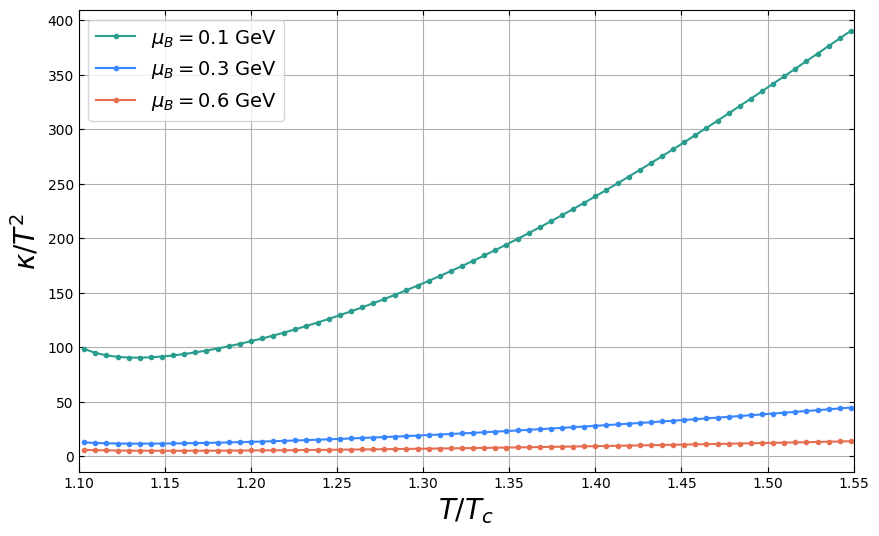

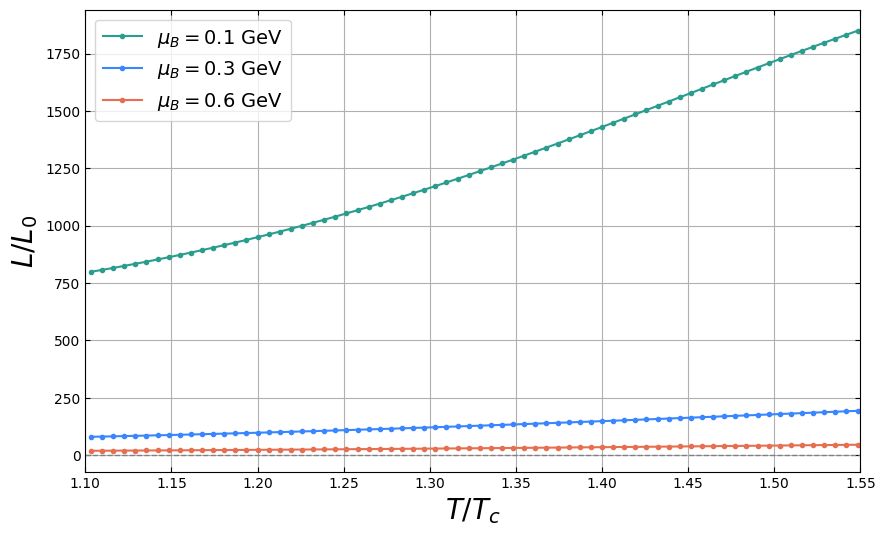

In [51]:
# Block 11  (plots)

plot_fixed_muB(cond, "kapT2", r"$\kappa/T^2$", "kappabyT2.jpg")
plot_fixed_muB(cond, "LR",    r"$L/L_0$",      "LorenzRatio.jpg", hline=1)

In [52]:
# Block 12
# Save everything to one CSV

rows = []
for muB_val in muB_list:
    for k in range(len(emu[muB_val]["T"])):
        rows.append({
            "T": emu[muB_val]["T"][k], "MuB": muB_val,
            "m_ud": emu[muB_val]["mud"][k], "m_s": emu[muB_val]["ms"][k], "m_g": emu[muB_val]["mg"][k],
            "xi": emu[muB_val]["xi"][k],
            "tau_q_fm": tau[muB_val]["tq"][k], "tau_g_fm": tau[muB_val]["tg"][k],
            "sigma/T": trans[muB_val]["sigT"][k],
            "kappa0/T2": cond[muB_val]["kap0T2"][k], "kappa/T2": cond[muB_val]["kapT2"][k],
            "L": cond[muB_val]["L"][k], "L/L0": cond[muB_val]["LR"][k],
        })

pd.DataFrame(rows).to_csv("transport_B0_fixed_MuB.csv", index=False)
print("saved transport_B0_fixed_MuB.csv")

saved transport_B0_fixed_MuB.csv
